<a href="https://colab.research.google.com/github/dosb94/ml-playground/blob/main/Neural_Nets_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

import keras

In [ ]:
url = "https://github.com/dragonnomada/ia-cic-febrero-2026/" + \
  "blob/main/conjuntos/casas.csv?raw=true"

casas = pandas.read_csv(url)

casas.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
casas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
y = casas["SalePrice"]

<Axes: xlabel='SalePrice', ylabel='Density'>

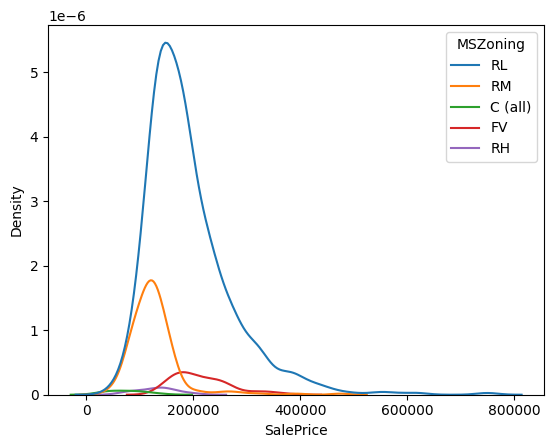

In [ ]:
seaborn.kdeplot(x=y, hue=casas["MSZoning"])

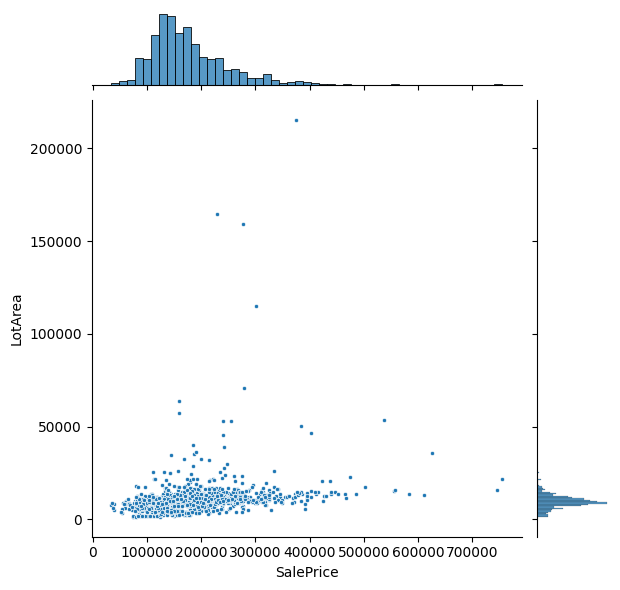

In [ ]:
seaborn.jointplot(x=y, y=casas["LotArea"], marker=".")

<Axes: xlabel='SalePrice', ylabel='Density'>

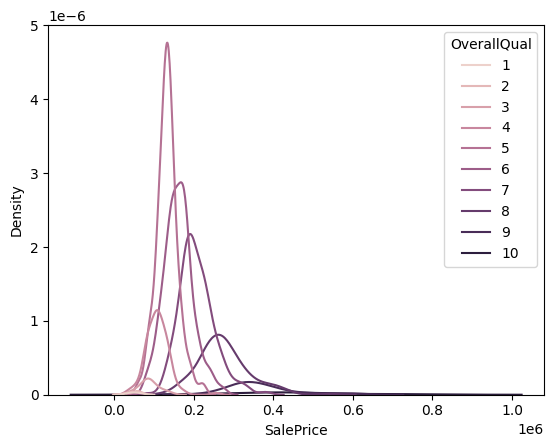

In [ ]:
seaborn.kdeplot(x=y, hue=casas["OverallQual"])

<Axes: xlabel='SalePrice', ylabel='Density'>

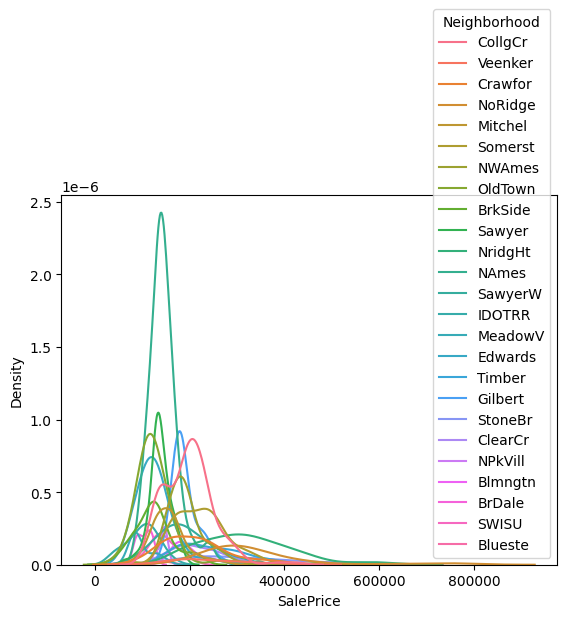

In [ ]:
seaborn.kdeplot(x=y, hue=casas["Neighborhood"])

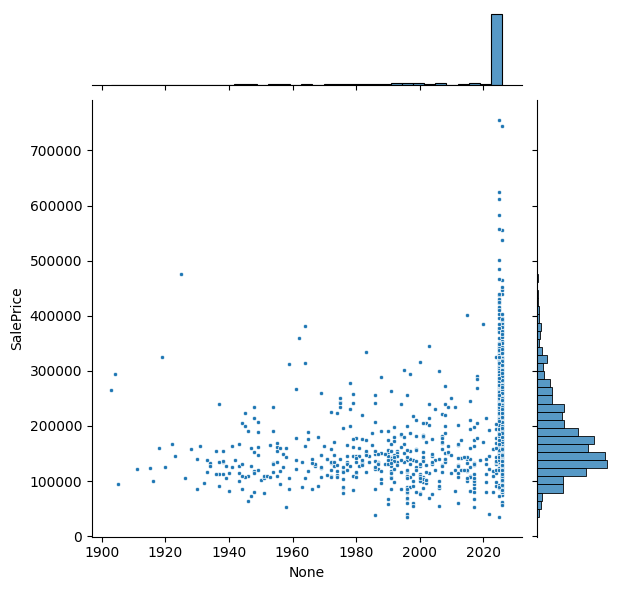

In [ ]:
seaborn.jointplot(y=y,
    x=(2026 - casas["YearRemodAdd"] + casas["YearBuilt"]),
    marker=".")

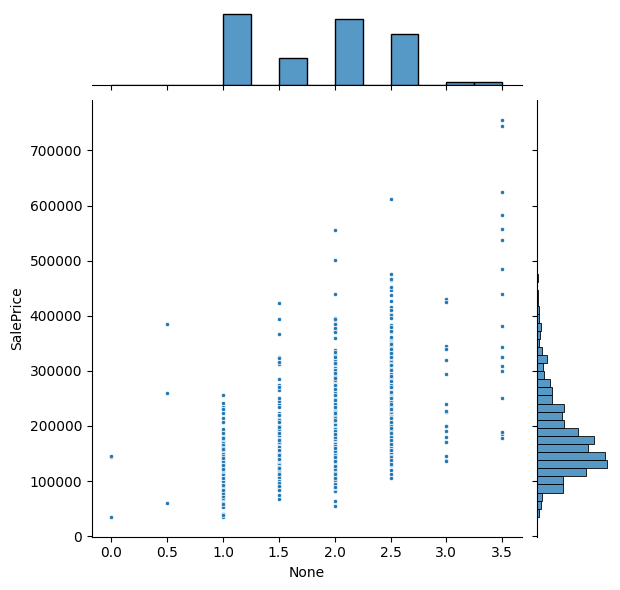

In [ ]:
seaborn.jointplot(y=y,
    x=casas["FullBath"] + 0.5 * casas["HalfBath"],
    marker=".")

<Axes: xlabel='SalePrice', ylabel='Density'>

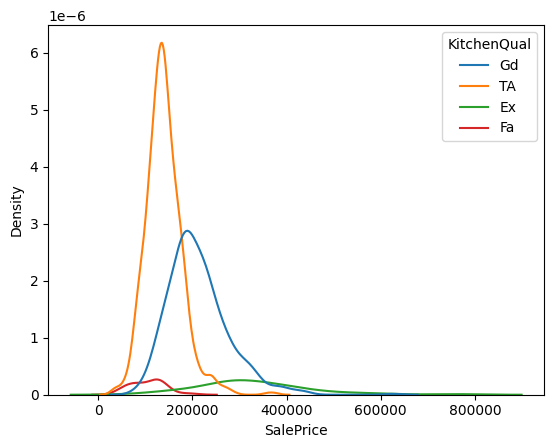

In [ ]:
seaborn.kdeplot(x=y, hue=casas["KitchenQual"])

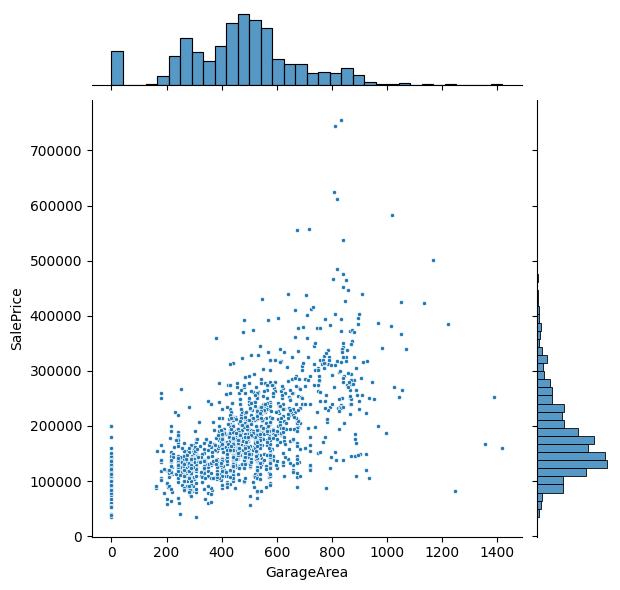

In [ ]:
seaborn.jointplot(y=y,
    x=casas["GarageArea"],
    marker=".")

In [ ]:
casas["LotArea"].quantile(0.95)

np.float64(17401.149999999998)

In [ ]:
x1 = casas["MSZoning"] == "RH"
x2 = casas["MSZoning"] == "RM"
x3 = casas["MSZoning"] == "C (all)"
x4 = casas["MSZoning"] == "FV"

x5 = casas["LotArea"]
x6 = casas["LotArea"] > casas["LotArea"].quantile(0.95)

x7 = casas["OverallQual"]

x8 = casas["YearBuilt"]
x9 = casas["YearRemodAdd"]
x10 = 2026 - casas["YearRemodAdd"] + casas["YearBuilt"]

x11 = casas["FullBath"]
x12 = casas["HalfBath"]
x13 = casas["FullBath"] + 0.5 * casas["HalfBath"]

x14 = casas["KitchenQual"] == "Fa"
x15 = casas["KitchenQual"] == "Gd"
x16 = casas["KitchenQual"] == "Ex"

x17 = casas["GarageArea"]
x18 = casas["GarageArea"] > casas["GarageArea"].quantile(0.95)

x19 = casas["MoSold"]
x20 = casas["YrSold"]

In [ ]:
X = pandas.DataFrame([
    x1, x2, x3, x4,
     x5, x6, x7, x8, x9,
     x10, x11, x12, x13, x14,
     x15, x16, x17, x18, x19, x20
]).T

X

,MSZoning,MSZoning,MSZoning,MSZoning,LotArea,LotArea,OverallQual,YearBuilt,YearRemodAdd,Unnamed 0,FullBath,HalfBath,Unnamed 1,KitchenQual,KitchenQual,KitchenQual,GarageArea,GarageArea,MoSold,YrSold
0,0.0,0.0,0.0,0.0,8450.0,0.0,7.0,2003.0,2003.0,2026.0,2.0,1.0,2.5,0.0,1.0,0.0,548.0,0.0,2.0,2008.0
1,0.0,0.0,0.0,0.0,9600.0,0.0,6.0,1976.0,1976.0,2026.0,2.0,0.0,2.0,0.0,0.0,0.0,460.0,0.0,5.0,2007.0
2,0.0,0.0,0.0,0.0,11250.0,0.0,7.0,2001.0,2002.0,2025.0,2.0,1.0,2.5,0.0,1.0,0.0,608.0,0.0,9.0,2008.0
3,0.0,0.0,0.0,0.0,9550.0,0.0,7.0,1915.0,1970.0,1971.0,1.0,0.0,1.0,0.0,1.0,0.0,642.0,0.0,2.0,2006.0
4,0.0,0.0,0.0,0.0,14260.0,0.0,8.0,2000.0,2000.0,2026.0,2.0,1.0,2.5,0.0,1.0,0.0,836.0,0.0,12.0,2008.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.0,0.0,0.0,0.0,7917.0,0.0,6.0,1999.0,2000.0,2025.0,2.0,1.0,2.5,0.0,0.0,0.0,460.0,0.0,8.0,2007.0
1456,0.0,0.0,0.0,0.0,13175.0,0.0,6.0,1978.0,1988.0,2016.0,2.0,0.0,2.0,0.0,0.0,0.0,500.0,0.0,2.0,2010.0
1457,0.0,0.0,0.0,0.0,9042.0,0.0,7.0,1941.0,2006.0,1961.0,2.0,0.0,2.0,0.0,1.0,0.0,252.0,0.0,5.0,2010.0
1458,0.0,0.0,0.0,0.0,9717.0,0.0,5.0,1950.0,1996.0,1980.0,1.0,0.0,1.0,0.0,1.0,0.0,240.0,0.0,4.0,2010.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
modelo = keras.Sequential([
    keras.Input(shape=(20,)),
    keras.layers.Dense(1400, activation="relu"),
    keras.layers.Dense(400, activation="relu"),
    keras.layers.Dense(400, activation="relu"),
    keras.layers.Dense(400, activation="relu"),
    keras.layers.Dense(400, activation="relu"),
    keras.layers.Dense(400, activation="relu"),
    keras.layers.Dense(1, activation="relu"),
])

modelo.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse", "mae"]
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1400)           │        29,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 400)            │       560,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231,801 (4.70 MB)

 Trainable params: 1,231,801 (4.70 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
modelo.fit(X_train, y_train, epochs=1000, batch_size=140)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 38697562112.0000 - mae: 181450.9062 - mse: 38697562112.0000
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 38128836608.0000 - mae: 181280.2188 - mse: 38128832512.0000
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 37888995328.0000 - mae: 179577.8438 - mse: 37888995328.0000
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 38349434880.0000 - mae: 180157.6562 - mse: 38349434880.0000
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 38878609408.0000 - mae: 182427.2969 - mse: 38878609408.0000
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 38080962560.0000 - mae: 180057.8750 - mse: 38080962560.0000
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 40166481920.0000 - mae: 184795.4531 - mse: 40166481920.0000
Epoch 8/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 37699297280.0000 - mae: 180001.7188 - mse: 37699301376.0000
Epoch 9/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/st